In [21]:
# Pour la manipulation de tableaux
import numpy as np

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import f1_score, accuracy_score, classification_report
import tensorflow as tf

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical 

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import keras




In [22]:


# %%
val_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split/validation/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='grayscale'
)



# %%
test_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split/test/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    seed = 42,
    shuffle=False,
    color_mode='grayscale'
)



Found 2083 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.


In [23]:
@keras.saving.register_keras_serializable()
class SparseF1Score(tf.keras.metrics.F1Score):
    """F1Score de Keras adaptée aux labels sparses (entiers) plutôt que one-hot."""
    def __init__(self, num_classes=4, **kwargs):
        super().__init__(**kwargs)
        self.num_classes_ = num_classes

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), depth=self.num_classes_)
        return super().update_state(y_true, y_pred, sample_weight)
    


In [24]:
model_loaded = load_model('cnn_128_l2_weight.keras')

model_loaded.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 299, 299, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 299, 299, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer1 (Conv2D)            │ (None, 299, 299, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization1             │ (None, 299, 299, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer1              │ (None, 149, 149, 32)   │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer2 (Conv2D)            │ (None, 149, 149, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization2             │ (None, 149, 149, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer2              │ (None, 74, 74, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer3 (Conv2D)            │ (None, 74, 74, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization3             │ (None, 74, 74, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_layer3              │ (None, 37, 37, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden_layer (Dense)      │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,894 (1.26 MB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 220,298 (860.54 KB)

In [25]:

# jeu de test
test_pred = model_loaded.predict(test_ds)
test_pred_class = test_pred.argmax(axis=1)
y_true_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)

# jeu de validation
val_pred = model_loaded.predict(val_ds)
val_pred_class = val_pred.argmax(axis=1)
y_true_val_class = np.concatenate([labels for images,labels in val_ds] ,axis=0)



66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 333ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step


              precision    recall  f1-score   support

           0       0.82      0.87      0.85       337
           1       0.88      0.86      0.87       599
           2       0.93      0.92      0.93      1014
           3       0.99      1.00      1.00       134

    accuracy                           0.90      2084
   macro avg       0.91      0.91      0.91      2084
weighted avg       0.90      0.90      0.90      2084



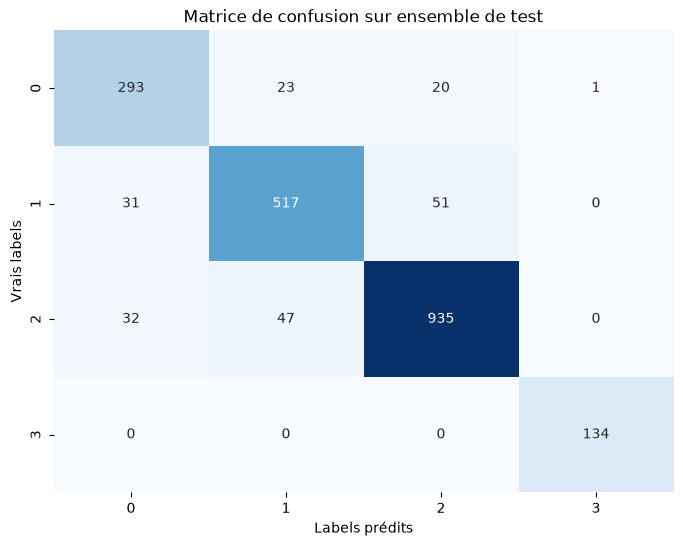

In [26]:
# Pour avoir le nom des classes (des poissons)
class_names = test_ds.class_names

print(metrics.classification_report(y_true_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_test_class, test_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


              precision    recall  f1-score   support

           0       0.82      0.85      0.83       338
           1       0.86      0.87      0.87       598
           2       0.93      0.92      0.93      1013
           3       0.99      0.99      0.99       134

    accuracy                           0.90      2083
   macro avg       0.90      0.91      0.91      2083
weighted avg       0.90      0.90      0.90      2083



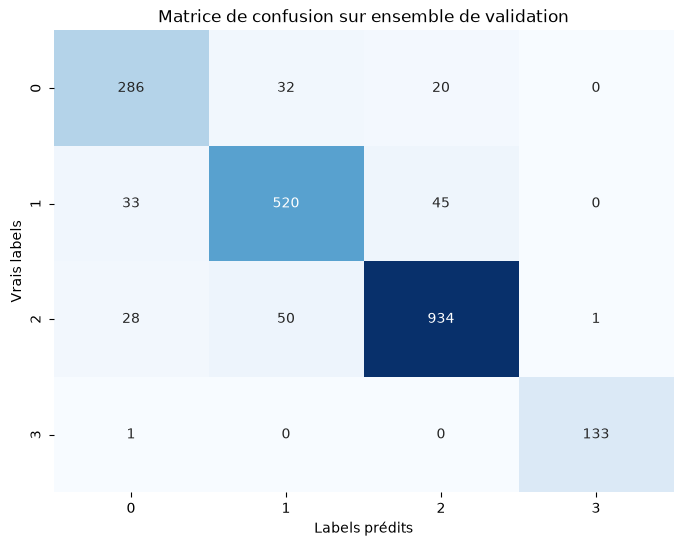

In [27]:
print(metrics.classification_report(y_true_val_class, val_pred_class))


# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_val_class, val_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de validation")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()
